# Libraries

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
from sklearn.linear_model import LinearRegression

# 1) Functions

In [7]:
def load_datasets(path1, path2, path3):

    df = pd.read_csv(path1, sep = ";")
    df['year'] = pd.to_datetime(df['year'], format = '%d/%m/%Y')
    #-----------------------------------------------------------------------------------------
    df1 = pd.read_csv(path2, sep = ";")
    #-----------------------------------------------------------------------------------------
    df2 = pd.read_csv(path3, sep = ";")
    df2['date_start'] = pd.to_datetime(df2['date_start'], dayfirst = False, format = 'mixed')
    df2['date_end'] = pd.to_datetime(df2['date_end'], dayfirst = False, format = 'mixed')
    df2['days'] = (df2['date_end'] - df2['date_start']).dt.days
    p1 = df2.loc[df2['site'] == 'P1', :].reset_index(drop=True)
    p2 = df2.loc[df2['site'] == 'P2', :].reset_index(drop=True)
    p3 = df2.loc[df2['site'] == 'P3', :].reset_index(drop=True)
    
    return df, df1, p1, p2, p3
#------------------------------------------------------------------------------------
def temporal_series(dataframe):

    fig1, axs = plt.subplots(figsize = (8,6))
    fig1.tight_layout(pad = 3)
    fig1.suptitle('Temporal series of resident population and land use/land cover', fontsize = 13)
    axs.plot(dataframe['year'], dataframe['urban'], color = 'red')
    axs.tick_params(axis='y', labelcolor= 'red')
    axs.set_ylabel('Urban area (ha)', color = 'red', fontsize = 12, labelpad = 10)
    axs.set_yticks([0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500])
    
    ax2 = axs.twinx()

    ax2.plot(df['year'], df['population'], color = 'black')
    ax2.set_ylabel('Resident population', color = 'black', rotation = -90, fontsize = 12, labelpad = 15)
    ax2.tick_params(axis='y', labelcolor= 'black')
    ax2.spines['right'].set_position(('outward', 0))
    ax2.set_yticks([0, 20000, 40000, 60000, 80000, 100000, 120000, 140000, 160000, 180000, 200000])

    ax3 = axs.twinx()

    ax3.plot(df['year'], df['forest'], color = 'green')
    ax3.set_ylabel('Forest (ha)', color = 'green', fontsize = 12, labelpad = 10)
    ax3.tick_params(axis='y', labelcolor= 'green')
    ax3.spines['right'].set_position(('axes', -0.25))
    ax3.set_yticks([0, 2600, 5200, 7800, 10400, 13000, 15600, 18200, 20800, 23400, 26000])
    ax3.yaxis.set_label_coords(-0.3, 0.5)

    ax4 = axs.twinx()

    ax4.plot(df['year'], df['agriculture'], color = 'orange')
    ax4.set_ylabel('Agriculture (ha)', color = 'orange', fontsize = 12, labelpad = 10)
    ax4.tick_params(axis='y', labelcolor= 'orange')
    ax4.spines['right'].set_position(('axes', -0.44))
    ax4.set_yticks([0, 10000, 20000, 30000, 40000, 50000, 60000, 70000, 80000, 90000, 100000])
    ax4.yaxis.set_label_coords(-0.49, 0.5)

    ax5 = axs.twinx()
    
    ax5.plot(df['year'], df['water'], color = 'blue')
    ax5.set_ylabel('Water (ha)', color = 'blue', fontsize = 12, labelpad = 10)
    ax5.tick_params(axis='y', labelcolor= 'blue')
    ax5.spines['right'].set_position(('axes', -0.63))
    ax5.set_yticks([0, 300, 600, 900, 1200, 1500, 1800, 2100, 2400, 2700, 3000])
    ax5.yaxis.set_label_coords(-0.68, 0.5)

    plt.savefig('../figures/figure_1.jpeg', bbox_inches='tight')
    plt.close(fig1)
#------------------------------------------------------------------------------------
def monthly_electricity_consumption(dataframe):

    fig2, ax = plt.subplots(figsize=(12,5))

    ax.set_xlabel('Month/Year')
    ax.set_ylabel('Residential Monthly Electricity Consumption (Mwh)', color='black')
    ax.plot(dataframe['month_year'], dataframe['monthly_electricity_consumption'], color='black')
    ax.tick_params(axis='y', labelsize = 9)
    ax.tick_params(axis='x', labelrotation = 90, labelsize = 4)

    plt.savefig('../figures/figure_2.jpeg', bbox_inches='tight')
    plt.close(fig2)
#------------------------------------------------------------------------------------
def elemental_contents(p1, p2, p3):

    P1 = [
         ["P1", "P1", "P1", 'P1', "P1", "P1", "P1", 'P1', "P1", "P1", "P1", 'P1'],
         ['Sep-Oct/22', 'Oct-Nov/22', 'Nov-Dec/22', 'Dec-Jan/23', 'Jan-Feb/23', 'Feb-Mar/23', 'Mar-Apr/23', 'Apr-May/23', 'May-Jun/23', 'Jun-Jul/23', 'Jul-Aug/23', 'Aug-Sep/23']
         ]
    
    P2 = [
         ["P2", "P2", "P2", 'P2', "P2", "P2", "P2", 'P2', "P2", "P2", "P2", 'P2'],
         ['Sep-Oct/22', 'Oct-Nov/22', 'Nov-Dec/22', 'Dec-Jan/23', 'Jan-Feb/23', 'Feb-Mar/23', 'Mar-Apr/23', 'Apr-May/23', 'May-Jun/23', 'Jun-Jul/23', 'Jul-Aug/23', 'Aug-Sep/23']
         ]
    
    P3 = [
         ["P3", "P3", "P3", "P3", "P3", "P3", "P3", "P3", "P3", "P3", "P3", "P3"],
         ['Sep-Oct/22', 'Oct-Nov/22', 'Nov-Dec/22', 'Dec-Jan/23', 'Jan-Feb/23', 'Feb-Mar/23', 'Mar-Apr/23', 'Apr-May/23', 'May-Jun/23', 'Jun-Jul/23', 'Jul-Aug/23', 'Aug-Sep/23']
         ]
    #--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    fig3 = make_subplots(rows=3, cols=2, vertical_spacing=0.25, horizontal_spacing=0.1)
    fig3.update_yaxes(linecolor='black')
    fig3.update_xaxes(linecolor='black')
    fig3.update_yaxes(ticks="outside")
    
    fig3.add_trace(go.Bar(x = P1, y = p1['oc'], name = 'OC', marker_color = 'gray', orientation = 'v'), row = 1, col = 1)
    fig3.add_trace(go.Bar(x = P1, y = p1['tn'], name = 'TN', marker_color = 'red', orientation = 'v'), row = 1, col = 1)
    fig3.update_layout(barmode = 'stack', plot_bgcolor = 'white')
    fig3.update_yaxes(title_text = "Contents (%)", range=[0, 3], row=1, col=1)
    fig3.update_traces(marker_line_color='rgb(0,0,0)', marker_line_width=1, row = 1, col = 1)
    #--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    fig3.add_trace(go.Bar(x = P2, y = p2['oc'], marker_color = 'gray', orientation = 'v', showlegend = False), row = 2, col = 1)
    fig3.add_trace(go.Bar(x = P2, y = p2['tn'], marker_color = 'red', orientation = 'v', showlegend = False), row = 2, col = 1)
    fig3.update_layout(barmode = 'stack', plot_bgcolor = 'white')
    fig3.update_yaxes(title_text = "Contents (%)", range=[0, 3], row=2, col=1)
    fig3.update_traces(marker_line_color='rgb(0,0,0)', marker_line_width=1, row = 2, col = 1)
    #--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    fig3.add_trace(go.Bar(x = P3, y = p3['oc'], marker_color = 'gray', orientation = 'v', showlegend = False), row = 3, col = 1)
    fig3.add_trace(go.Bar(x = P3, y = p3['tn'], marker_color = 'red', orientation = 'v', showlegend = False), row = 3, col = 1)
    fig3.update_layout(barmode = 'stack', plot_bgcolor = 'white')
    fig3.update_yaxes(title_text = "Contents (%)", range=[0, 3], row=3, col=1)
    fig3.update_traces(marker_line_color='rgb(0,0,0)', marker_line_width=1, row = 3, col = 1)
    #--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    fig3.add_trace(go.Scatter(x = P1, y = p1['CN_ratio'], name = 'C/N ratio', mode='lines+markers', line_color='#000000', showlegend = False), row = 1, col = 2)
    fig3.update_yaxes(range=[6, 10], row=1, col=2)
    
    fig3.add_trace(go.Scatter(x = P2, y = p2['CN_ratio'], name = 'C/N ratio', mode='lines+markers', line_color='#000000', showlegend = False), row = 2, col = 2)
    fig3.update_yaxes(range=[6, 10], row=2, col=2)
    
    fig3.add_trace(go.Scatter(x = P3, y = p3['CN_ratio'], name = 'C/N ratio', mode='lines+markers', line_color='#000000', showlegend = True), row = 3, col = 2)
    fig3.update_yaxes(range=[6, 10], row=3, col=2)
    #--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    fig3.update_layout(
        width=1000,
        height=800,
        title_text="Temporal variation of elemental contents and (C/N) ratio"
    )

    return fig3
#------------------------------------------------------------------------------------
def isotope_ratios(p1, p2, p3):

    P1 = [
         ["P1", "P1", "P1", 'P1', "P1", "P1", "P1", 'P1', "P1", "P1", "P1", 'P1'],
         ['Sep-Oct/22', 'Oct-Nov/22', 'Nov-Dec/22', 'Dec-Jan/23', 'Jan-Feb/23', 'Feb-Mar/23', 'Mar-Apr/23', 'Apr-May/23', 'May-Jun/23', 'Jun-Jul/23', 'Jul-Aug/23', 'Aug-Sep/23']
         ]
    
    P2 = [
             ["P2", "P2", "P2", 'P2', "P2", "P2", "P2", 'P2', "P2", "P2", "P2", 'P2'],
             ['Sep-Oct/22', 'Oct-Nov/22', 'Nov-Dec/22', 'Dec-Jan/23', 'Jan-Feb/23', 'Feb-Mar/23', 'Mar-Apr/23', 'Apr-May/23', 'May-Jun/23', 'Jun-Jul/23', 'Jul-Aug/23', 'Aug-Sep/23']
             ]
        
    P3 = [
             ["P3", "P3", "P3", "P3", "P3", "P3", "P3", "P3", "P3", "P3", "P3", "P3"],
             ['Sep-Oct/22', 'Oct-Nov/22', 'Nov-Dec/22', 'Dec-Jan/23', 'Jan-Feb/23', 'Feb-Mar/23', 'Mar-Apr/23', 'Apr-May/23', 'May-Jun/23', 'Jun-Jul/23', 'Jul-Aug/23', 'Aug-Sep/23']
             ]
    #--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    fig5 = make_subplots(rows=3, cols=2, vertical_spacing=0.25, horizontal_spacing=0.1)
    fig5.update_yaxes(linecolor='black')
    fig5.update_xaxes(linecolor='black')
    fig5.update_yaxes(ticks="outside")
        
    fig5.add_trace(go.Scatter(x = P1, y = p1['delta_13C'], mode='lines+markers', line_color='#000000', showlegend = False), row = 1, col = 1)
    fig5.update_layout(plot_bgcolor = 'white')
    fig5.update_yaxes(title_text = "<i>\u03b4</i><sup>13</sup>C (‰)", range=[-22, -16], row=1, col=1)
    fig5.update_traces(marker_line_color='rgb(0,0,0)', marker_line_width=1, row = 1, col = 1)
    #--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    fig5.add_trace(go.Scatter(x = P2, y = p2['delta_13C'], mode='lines+markers', line_color='#000000', showlegend = False), row = 2, col = 1)
    fig5.update_layout(plot_bgcolor = 'white')
    fig5.update_yaxes(title_text = "<i>\u03b4</i><sup>13</sup>C (‰)", range=[-22, -16], row=2, col=1)
    fig5.update_traces(marker_line_color='rgb(0,0,0)', marker_line_width=1, row = 2, col = 1)
    #--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    fig5.add_trace(go.Scatter(x = P3, y = p3['delta_13C'], mode='lines+markers', line_color='#000000', showlegend = False), row = 3, col = 1)
    fig5.update_layout(plot_bgcolor = 'white')
    fig5.update_yaxes(title_text = "<i>\u03b4</i><sup>13</sup>C (‰)", range=[-22, -16], row=3, col=1)
    fig5.update_traces(marker_line_color='rgb(0,0,0)', marker_line_width=1, row = 3, col = 1)
    #--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    fig5.add_trace(go.Scatter(x = P1, y = p1['delta_15N'], mode='lines+markers', line_color='#000000', showlegend = False), row = 1, col = 2)
    fig5.update_yaxes(title_text = "<i>\u03b4</i><sup>15</sup>N (‰)", range=[1, 8], row=1, col=2)
        
    fig5.add_trace(go.Scatter(x = P2, y = p2['delta_15N'], mode='lines+markers', line_color='#000000', showlegend = False), row = 2, col = 2)
    fig5.update_yaxes(title_text = "<i>\u03b4</i><sup>15</sup>N (‰)", range=[1, 8], row=2, col=2)
        
    fig5.add_trace(go.Scatter(x = P3, y = p3['delta_15N'], mode='lines+markers', line_color='#000000', showlegend = True), row = 3, col = 2)
    fig5.update_yaxes(title_text = "<i>\u03b4</i><sup>15</sup>N (‰)", range=[1, 8], row=3, col=2)
    #--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    fig5.update_layout(
        width=1000,
        height=800,
        title_text="Temporal variation of stable carbon and nitrogen isotope ratios"
    )

    return fig5
#------------------------------------------------------------------------------------


# 2) Loading datasets

In [3]:
path1 = '../datasets/land_use_cover.csv'
path2 = '../datasets/monthly_electricity_consumption.csv'
path3 = '../datasets/elemental_isotopic_data.csv'

df = load_datasets(path1, path2, path3)[0]
df1 = load_datasets(path1, path2, path3)[1]
p1 = load_datasets(path1, path2, path3)[2]
p2 = load_datasets(path1, path2, path3)[3]
p3 = load_datasets(path1, path2, path3)[4]

# 3) Figures and Dataframes

<h4 style='text-align: justify; color: black;'><u>Figure 1</u> - Temporal series of ...</h4>

In [259]:
temporal_series(df)

<h4 style='text-align: justify; color: black;'><u>Figure 2</u> -  ...</h4>

In [330]:
monthly_electricity_consumption(df1)

<h4 style='text-align: justify; color: black;'><u>Figure 3</u> - ...</h4>

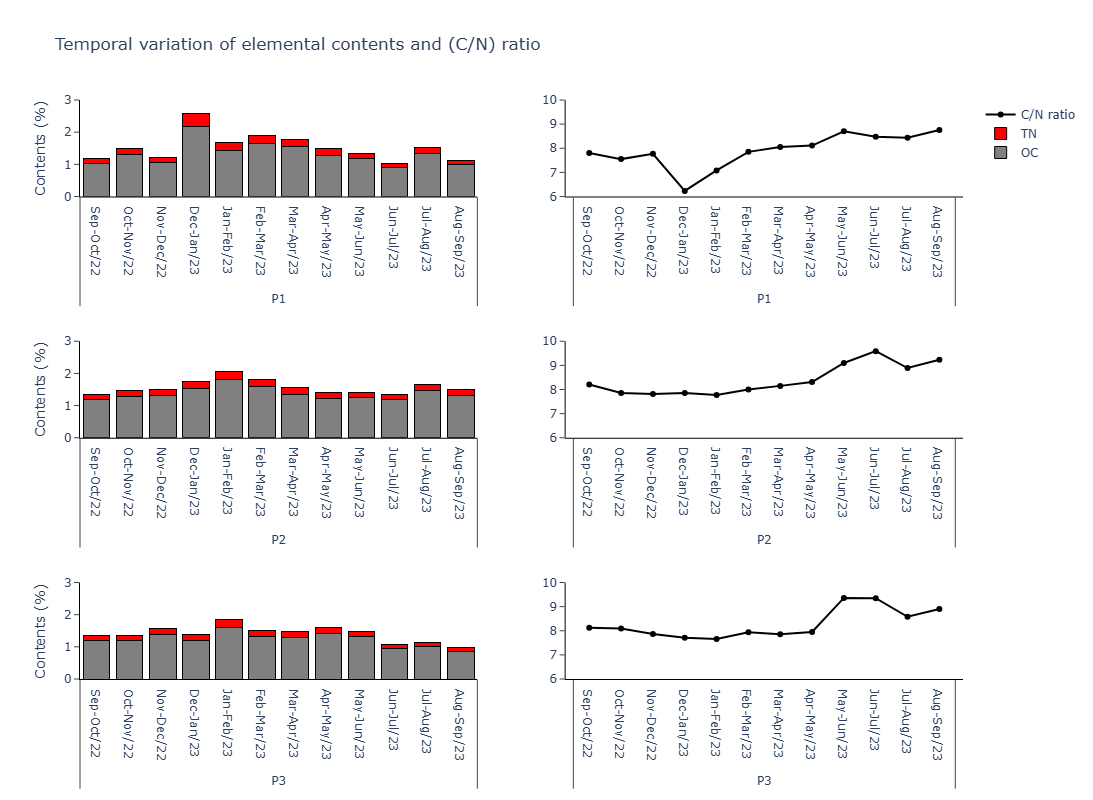

In [4]:
elemental_contents(p1, p2, p3)

<h4 style='text-align: justify; color: black;'><u>Figure 4</u> - ...</h4>

In [85]:
model_ = LinearRegression()
model_.fit(pd.concat([p1, p2, p3])['oc'], pd.concat([p1, p2, p3])['tn'])

ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

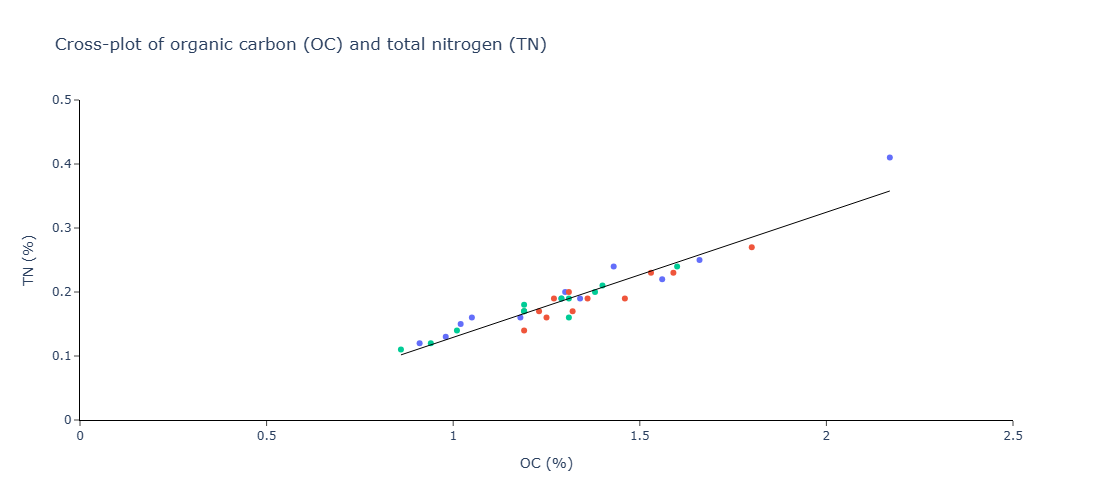

In [73]:
scatter = px.scatter(pd.concat([p1, p2, p3]), 
                     x = pd.concat([p1, p2, p3])['oc'], 
                     y = pd.concat([p1, p2, p3])['tn'],
                     color = pd.concat([p1, p2, p3])['site'],
                     trendline="ols",
                     trendline_scope="overall")

scatter.update_traces(line=dict(width=1, dash='solid'), line_color = 'black', selector=dict(mode='lines'))

fig4 = make_subplots(rows=1, cols=1)

fig4.update_layout(width = 600,
                   height = 500,
                   title_text="Cross-plot of organic carbon (OC) and total nitrogen (TN)", 
                   legend_title_text = 'Sites')
fig4.update_yaxes(linecolor='black')
fig4.update_xaxes(linecolor='black')
fig4.update_yaxes(ticks="outside")
fig4.update_xaxes(ticks="outside")

fig4.update_layout(plot_bgcolor = 'white')
fig4.update_yaxes(title_text = "TN (%)", range=[0, 0.5], row=1, col=1)
fig4.update_xaxes(title_text = "OC (%)", range=[0, 2.5], row=1, col=1)

for trace in scatter.data:
    fig4.add_trace(trace, row=1, col=1)

fig4

<h4 style='text-align: justify; color: black;'><u>Figure 5</u> - ...</h4>

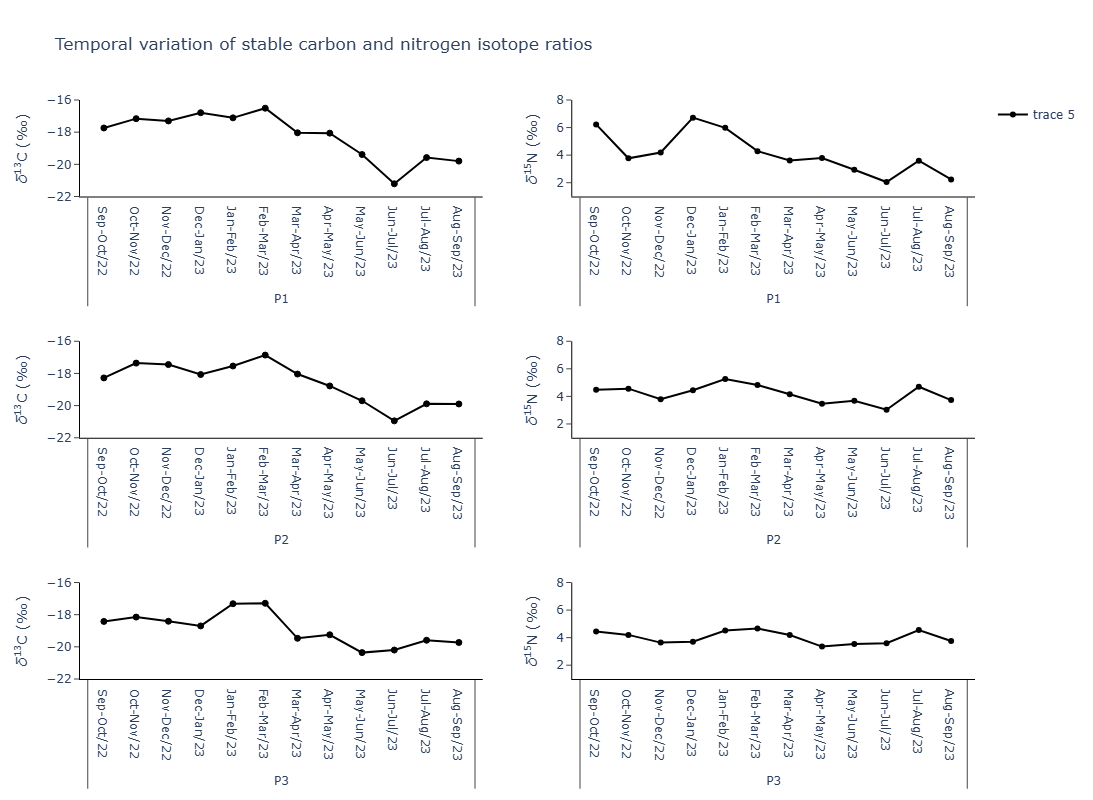

In [8]:
isotope_ratios(p1, p2, p3)

<h4 style='text-align: justify; color: black;'><u>Figure 6</u> - ...</h4>